In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

In [44]:
file = pd.ExcelFile('glass.xlsx')
abr = pd.read_excel(file, 'Description')
df = pd.read_excel(file, 'glass')

In [45]:
abr

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum
5,Si: Silicon
6,K:Potassium
7,Ca: Calcium
8,Ba: Barium
9,Fe: Iron


In [46]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [47]:
df.isnull().any()

,0
RI,False
Na,False
Mg,False
Al,False
Si,False
K,False
Ca,False
Ba,False
Fe,False
Type,False


In [48]:
df.duplicated().any()

np.True_

In [49]:
df.drop_duplicates(inplace=True)

In [50]:
df.duplicated().any()

np.False_

In [51]:
y = df[['Type']]
X = df.drop('Type', axis=1)

In [52]:
X

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


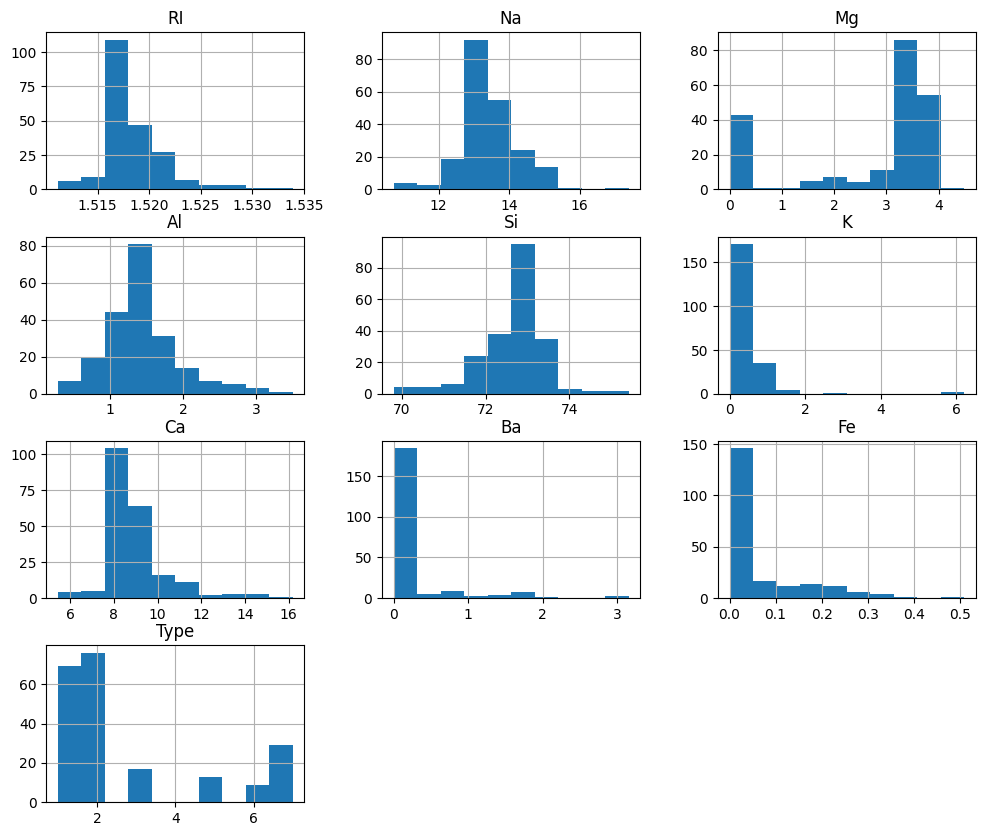

In [53]:
df.hist(figsize=(12,10))
plt.show()

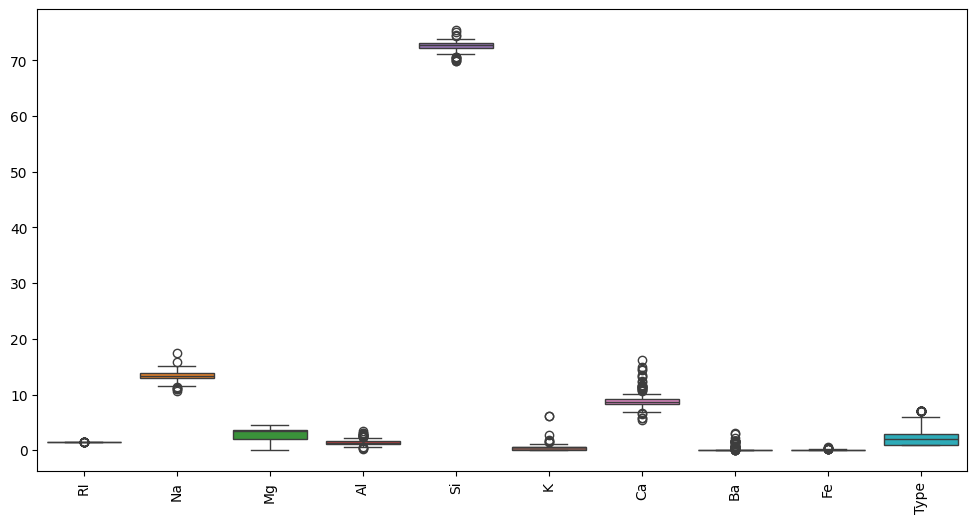

In [54]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

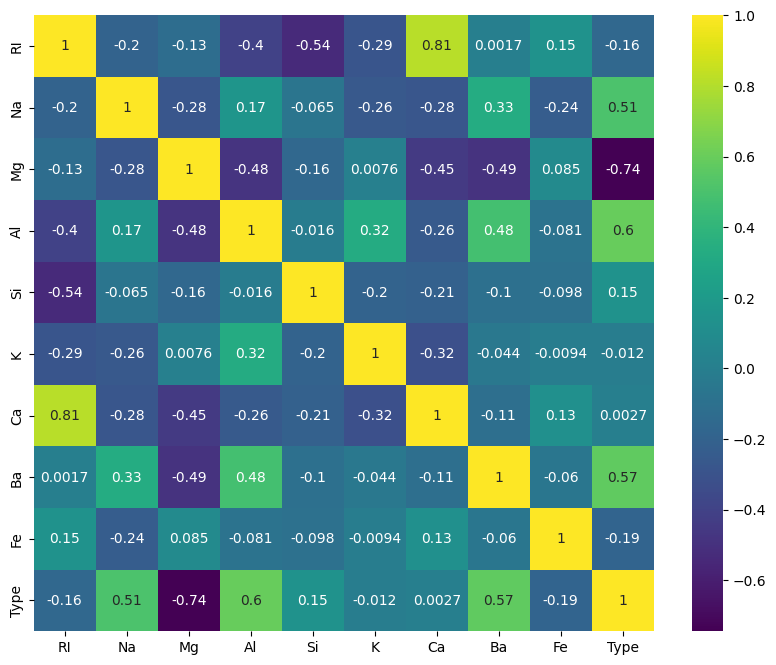

In [55]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='viridis')
plt.show()

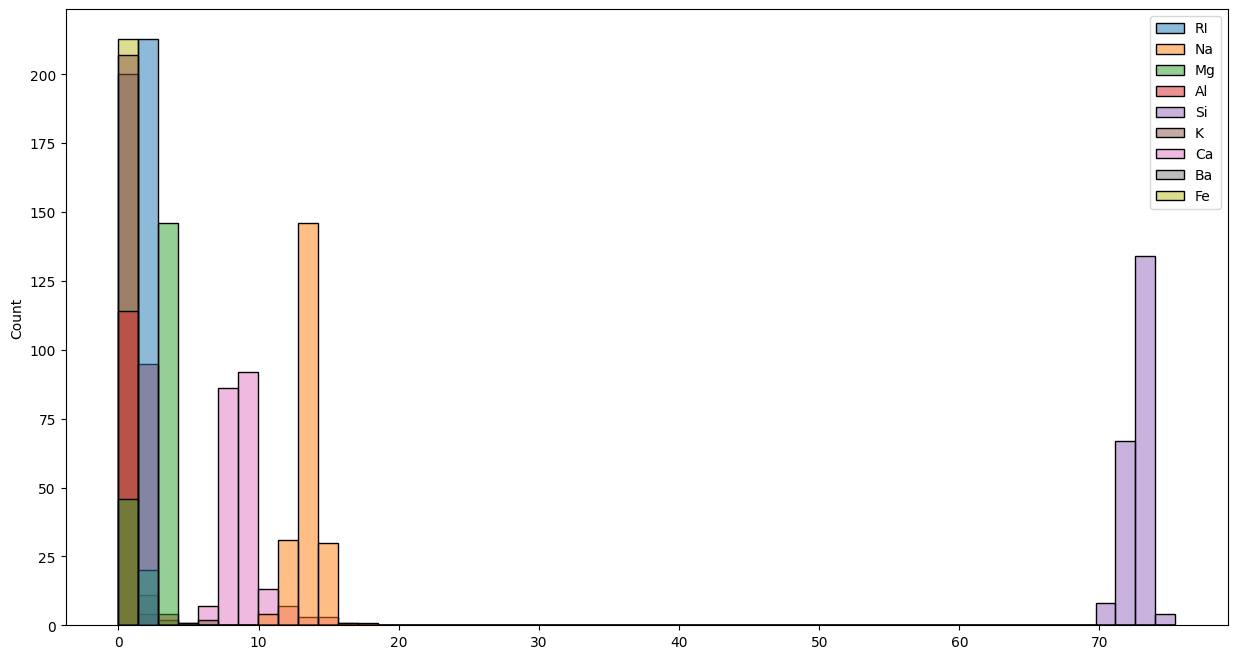

In [56]:
plt.figure(figsize=(15,8))
sns.histplot(X, kde=False)
plt.show()

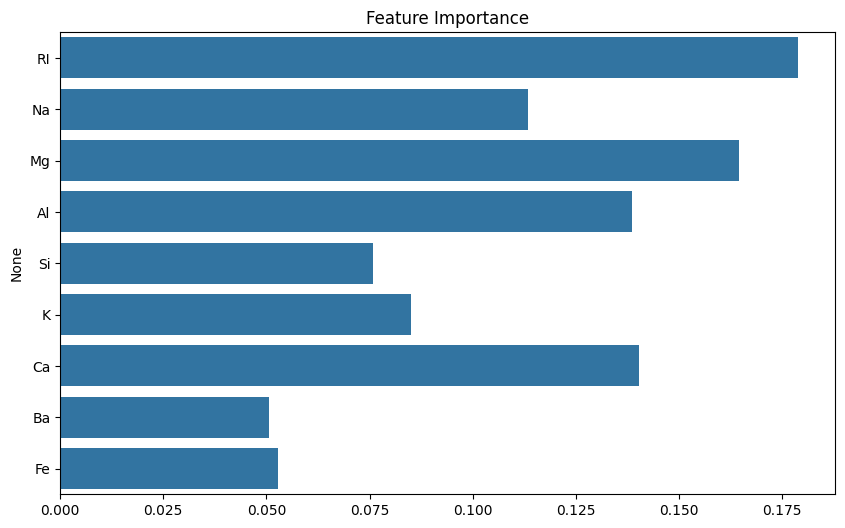

In [57]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

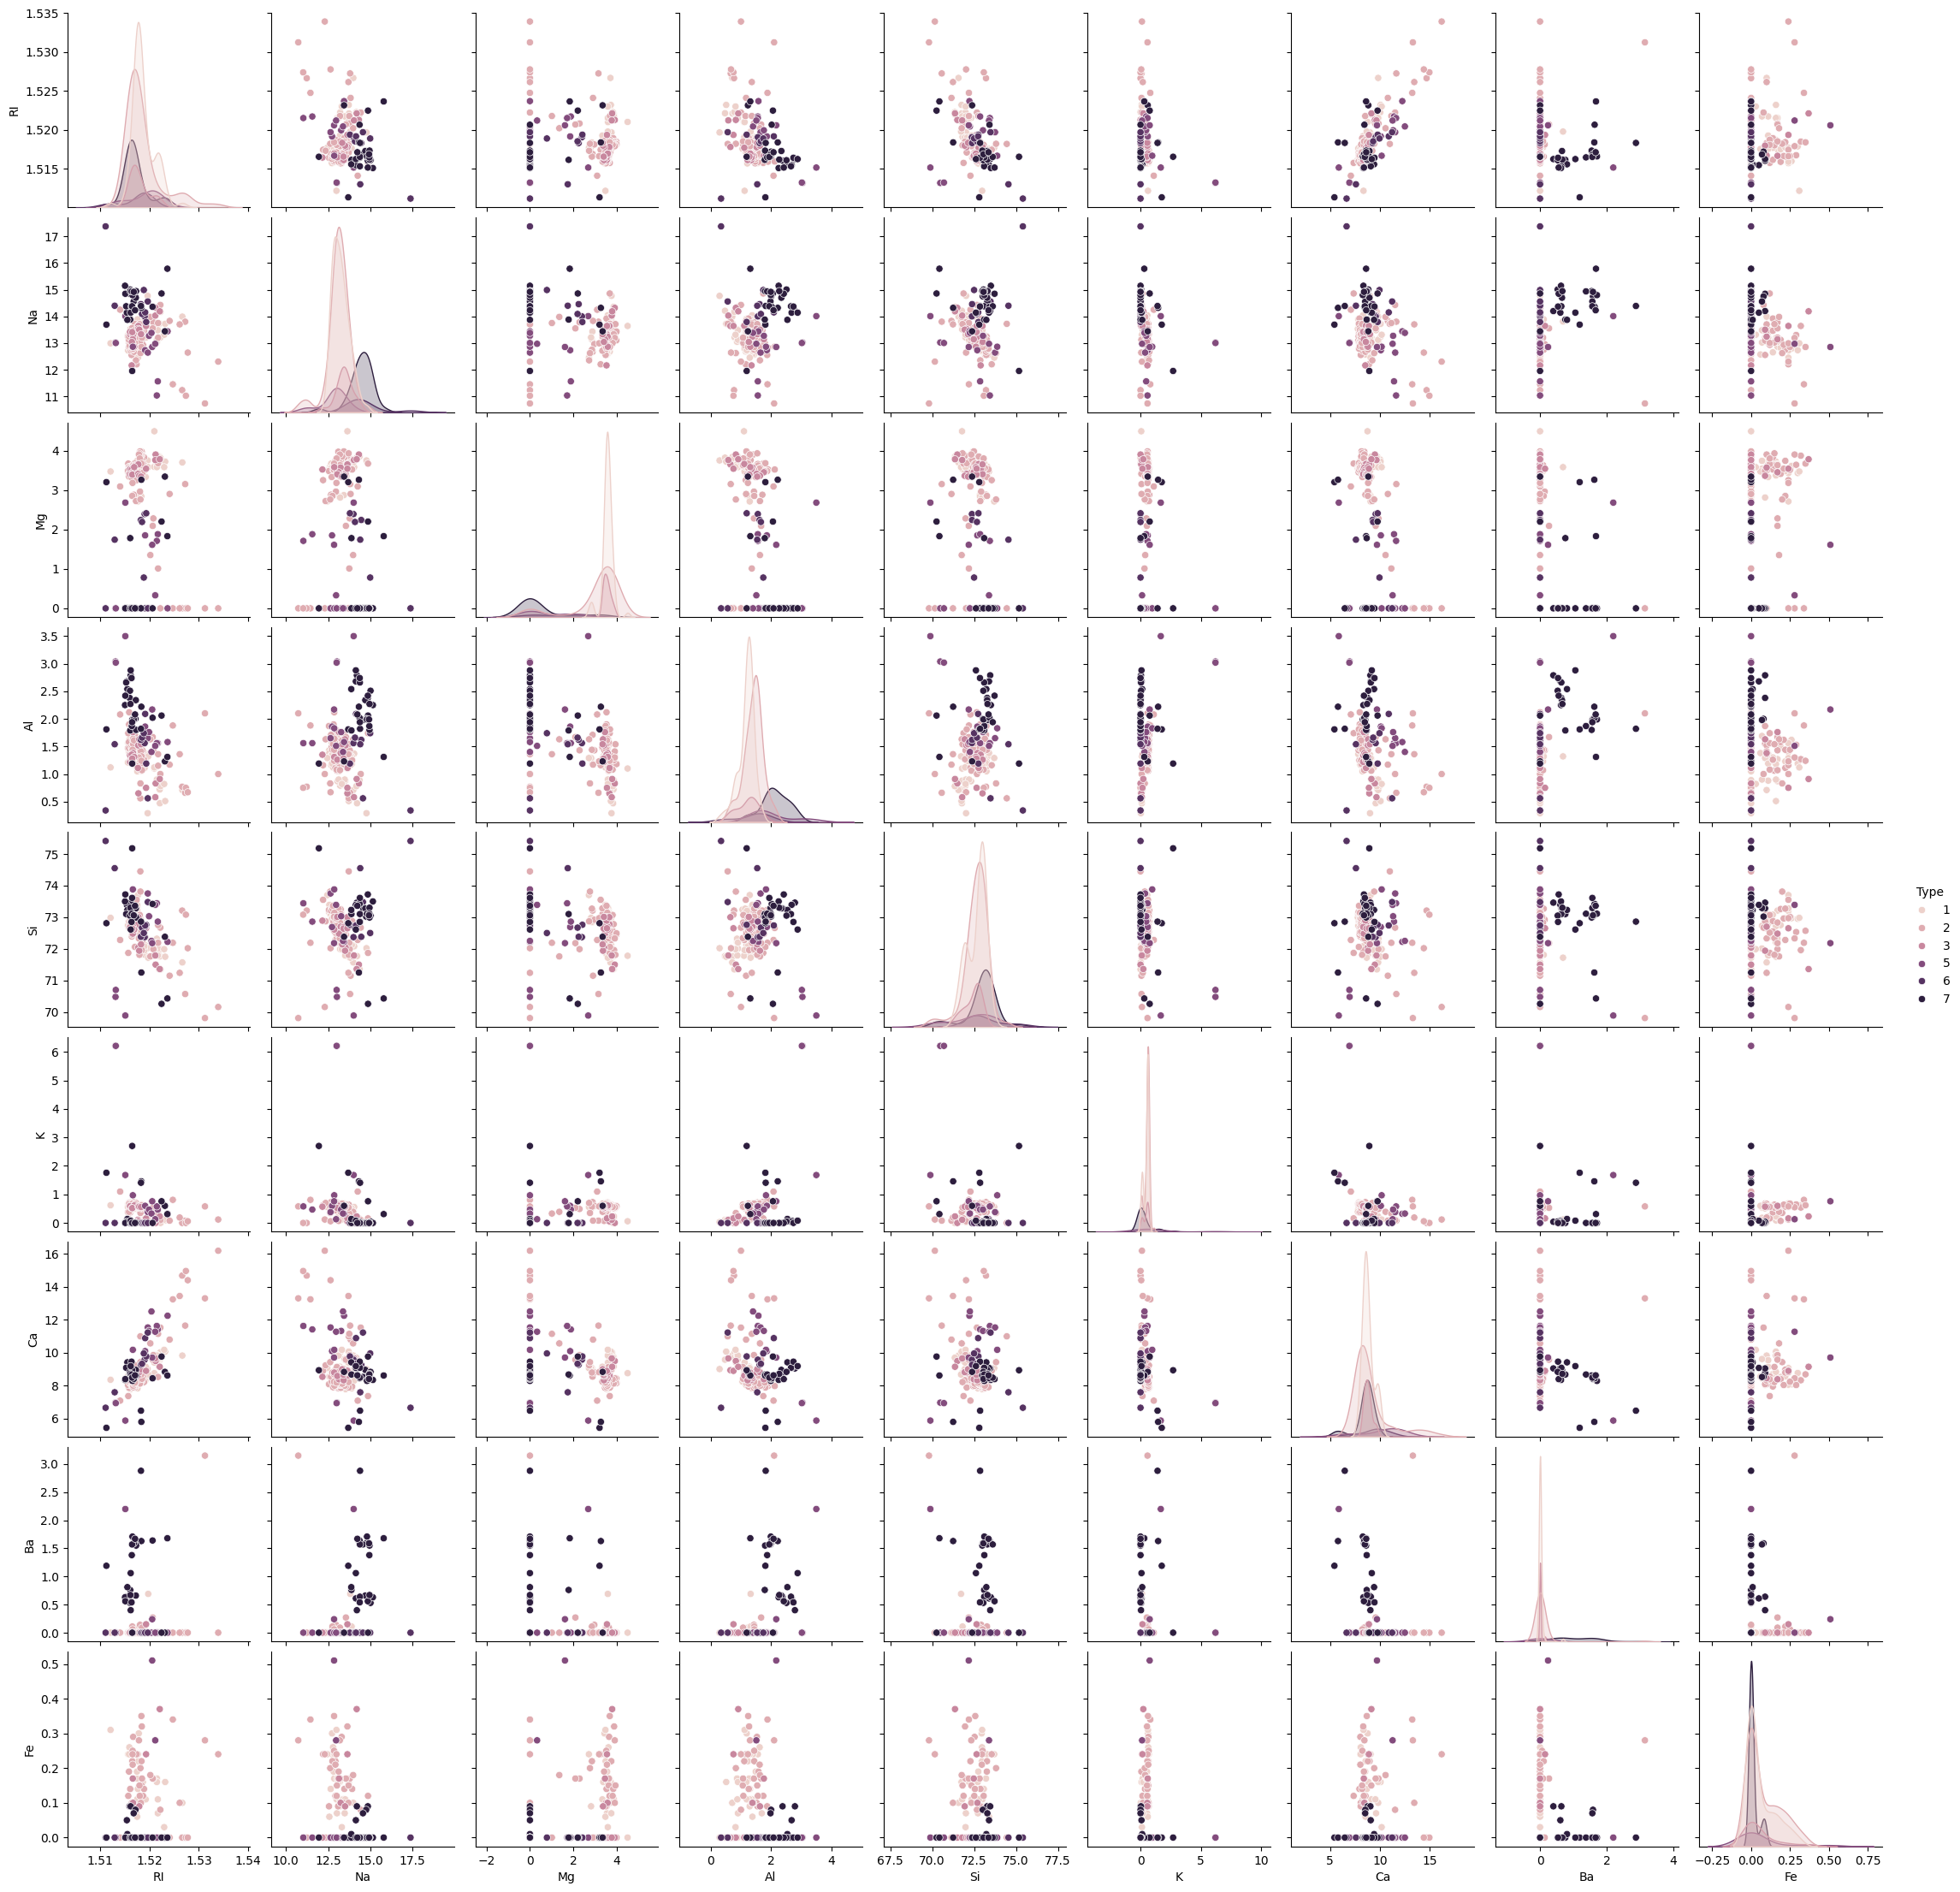

In [58]:
# Pairplot (important visualization)
sns.pairplot(df, hue='Type')
plt.show()

In [59]:
print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [60]:
for col in df.columns:
    if df[col].dtype != 'object':
        df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_1150/754084223.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [61]:
X = df.drop('Type', axis=1)
y = df['Type']

In [62]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [63]:
data = pd.concat([pd.DataFrame(X_scaled), y.reset_index(drop=True)], axis=1)

In [64]:
majority = data[data['Type'] == data['Type'].mode()[0]]
minority = data[data['Type'] != data['Type'].mode()[0]]

In [65]:
minority_upsampled = resample(minority,
                             replace=True,
                             n_samples=len(majority),
                             random_state=42)

In [66]:
balanced_data = pd.concat([majority, minority_upsampled])

In [67]:
X_bal = balanced_data.drop('Type', axis=1)
y_bal = balanced_data['Type']

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42
)

In [69]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [70]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9354838709677419

Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.88      0.93         8
           2       0.94      0.94      0.94        16
           3       0.00      0.00      0.00         0
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         4

    accuracy                           0.94        31
   macro avg       0.82      0.80      0.81        31
weighted avg       0.97      0.94      0.95        31


Confusion Matrix:
 [[ 7  1  0  0  0  0]
 [ 0 15  1  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  2  0  0]
 [ 0  0  0  0  1  0]
 [ 0  0  0  0  0  4]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [71]:
bag = BaggingClassifier(n_estimators=50, random_state=42)
bag.fit(X_train, y_train)

BaggingClassifier(n_estimators=50, random_state=42)

In [72]:
y_pred_bag = bag.predict(X_test)

In [73]:
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.8709677419354839


In [74]:
boost = AdaBoostClassifier(n_estimators=50, random_state=42)
boost.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

In [75]:
from sklearn.tree import DecisionTreeClassifier

# Improved AdaBoost
boost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

boost.fit(X_train, y_train)

y_pred_boost = boost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))
print("\nClassification Report:\n", classification_report(y_test, y_pred_boost))

Boosting Accuracy: 0.8387096774193549

Classification Report:
               precision    recall  f1-score   support

           1       0.78      0.88      0.82         8
           2       1.00      0.75      0.86        16
           3       0.00      0.00      0.00         0
           5       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         1
           7       0.80      1.00      0.89         4

    accuracy                           0.84        31
   macro avg       0.71      0.77      0.73        31
weighted avg       0.90      0.84      0.85        31



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [76]:
y_pred_boost = boost.predict(X_test)

In [77]:
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Boosting Accuracy: 0.8387096774193549


In [78]:
print("Random Forest:", accuracy_score(y_test, y_pred))
print("Bagging:", accuracy_score(y_test, y_pred_bag))
print("Boosting:", accuracy_score(y_test, y_pred_boost))

Random Forest: 0.9354838709677419
Bagging: 0.8709677419354839
Boosting: 0.8387096774193549


1. What is Bagging?

Bagging (Bootstrap Aggregating) is an ensemble learning technique used to improve model performance by reducing variance.

In Bagging, multiple models are trained on different subsets of the dataset (created using random sampling with replacement), and their predictions are combined to produce a final result.


 Steps:

Create multiple random subsets of the dataset.
Train a model on each subset independently.
Combine predictions using majority voting (classification) or averaging (regression).

 Advantages:
Reduces overfitting
Improves stability
Works well with high-variance models like Decision Trees

Example:
Random Forest is a popular Bagging-based algorithm

2. What is Boosting?

Boosting is an ensemble technique that combines multiple weak learners to create a strong learner by training models sequentially.

Each new model focuses on correcting the errors made by the previous models.

 Steps:
Train the first model.
Identify errors in prediction.
Give more importance (weight) to misclassified data.
Train the next model on updated data.
Repeat the process and combine results.

Advantages:
Reduces bias
Improves accuracy
Works well for complex datasets

Examples:
AdaBoost
Gradient Boosting

3. Difference Between Bagging and Boosting

| Feature     | Bagging                  | Boosting                    |
| ----------- | ------------------------ | --------------------------- |
| Training    | Parallel                 | Sequential                  |
| Goal        | Reduce variance          | Reduce bias                 |
| Sampling    | Random sampling          | Weighted sampling           |
| Overfitting | Helps reduce overfitting | Can overfit if not tuned    |
| Example     | Random Forest            | AdaBoost, Gradient Boosting |



4. How to Handle Imbalanced Data?

Imbalanced data occurs when one class has significantly more samples than others, which can lead to biased models.

Methods to Handle Imbalance:
1. Oversampling

Increase the number of samples in the minority class.

Example: Random Oversampling, SMOTE
2. Undersampling

Reduce the number of samples in the majority class.

3. Class Weighting

Assign higher importance to minority class during training.

In [79]:
RandomForestClassifier(class_weight='balanced')

RandomForestClassifier(class_weight='balanced')

SMOTE (Synthetic Minority Oversampling Technique)

Creates synthetic samples instead of duplicating data.

In [80]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)